In [ ]:
import sys
from pathlib import Path

repo_root = Path.cwd()
while repo_root != repo_root.parent and not (repo_root / "dllm").exists():
    repo_root = repo_root.parent
if (repo_root / "dllm").exists():
    sys.path.insert(0, str(repo_root))

import numpy as np
import torch
import matplotlib.pyplot as plt

from tool import TunedLens

from dllm import DLLMExpr
from dllm.DLLMBaseline import BaselineConfig

%matplotlib inline  
# 当引入外部文件发生变化时(如.py)自动刷新缓存，无需重启kernel
%load_ext autoreload
%autoreload 2

加载tuned lens

In [2]:
MODEL_PATH="/home/xiangzhong_ayl/dllm/works/dllm-research/models/LLaDA-8B-Instruct"
device = 'cuda:0'
token_info = {
    'mask_id': 126336,
    'bos_id': 126080,
    'pad_id': 126081,
    'eos_id': 126081,
    'eot_id': 126348
}
config = BaselineConfig(
    **token_info,
    remasking="low_confidence",
    positional_weights_type='none',
    decoding_method="fixed",
    factor=1,
    k=1,
    confidence_threshold=0.9,
)
sampler = DLLMExpr.from_path(model_path=MODEL_PATH, config=config)
tokenizer = sampler.tokenizer
model = sampler.model
model.to(device)


Loading model and tokenizer from path: /home/xiangzhong_ayl/dllm/works/dllm-research/models/LLaDA-8B-Instruct, dllm_type: llada


Loading checkpoint shards:   0%|          | 0/6 [00:00<?, ?it/s]

cfg_scale: 0.0
temperature: 0.0
mask_id: 126336
bos_id: 126080
pad_id: 126081
eos_id: 126081
eot_id: 126348
max_gen_length: 2048
max_steps: 2048
positional_weights_type: none
max_weight: 1.0
initial_min_weight: 0.05
ur_factor: 1.0
dllm_type: llada
remasking: low_confidence
decoding_method: fixed
k: 1
factor: 1
confidence_threshold: 0.9


LLaDAModelLM(
  (model): LLaDAModel(
    (transformer): ModuleDict(
      (wte): Embedding(126464, 4096)
      (emb_drop): Dropout(p=0.0, inplace=False)
      (ln_f): RMSLayerNorm()
      (blocks): ModuleList(
        (0-31): 32 x LLaDALlamaBlock(
          (dropout): Dropout(p=0.0, inplace=False)
          (act): SiLU()
          (attn_out): Linear(in_features=4096, out_features=4096, bias=False)
          (ff_out): Linear(in_features=12288, out_features=4096, bias=False)
          (rotary_emb): RotaryEmbedding()
          (attn_norm): RMSLayerNorm()
          (ff_norm): RMSLayerNorm()
          (q_proj): Linear(in_features=4096, out_features=4096, bias=False)
          (k_proj): Linear(in_features=4096, out_features=4096, bias=False)
          (v_proj): Linear(in_features=4096, out_features=4096, bias=False)
          (ff_proj): Linear(in_features=4096, out_features=12288, bias=False)
          (up_proj): Linear(in_features=4096, out_features=12288, bias=False)
        )
      )
    

SAVE outputs

In [3]:
from datasets import load_dataset
device = 'cuda:0'
gen_length = 192
block_length = 32

gsm8k_dataset = load_dataset('openai/gsm8k', 'main')
prompts = gsm8k_dataset['test']['question'][2:3]

for i, prompt_text in enumerate(prompts):
    print('=' * 20 + f" Generating prompt_idx: {i} " + "=" * 20)

    m = [{"role": "user", "content": prompt_text}]
    prompt_text = tokenizer.apply_chat_template(m, add_generation_prompt=True, tokenize=False)
    input_ids = tokenizer(prompt_text, return_tensors="pt").input_ids.to(device)

    OUT = sampler.generate(prompt=input_ids, gen_length=gen_length, max_steps=gen_length, block_length=block_length, records=['metrics', 'state_trace'])
    out = OUT.out
    ans = tokenizer.batch_decode(out[:, input_ids.shape[1]:], skip_special_tokens=True)[0]
    
    # 将hidden states保存到本地文件
    print(f"hidden_states shape: {OUT.state_trace['hidden_states_all'].shape}\n")
    np.save(f'{repo_root}/visualization/huashan2/data/hidden_states_gsm8k_qid_{i}_L{gen_length}.npy', OUT.state_trace['hidden_states_all'])

    # 将attentions保存到本地文件
    print(f"attentions shape: {OUT.state_trace['attentions_all'].shape}\n")
    np.save(f'{repo_root}/visualization/huashan2/data/attentions_gsm8k_qid_{i}_L{gen_length}.npy', OUT.state_trace['attentions_all'])


==================== Generating prompt_idx: 0 ====================
decoding method: fixed, k=1, factor=1, confidence_threshold=0.9.
adjusted gen_length: 192, n_blocks: 6.
hidden_states shape: (64, 33, 262, 4096)

attentions shape: (64, 32, 32, 262, 262)



tuned lens处理hidden states的输出

In [7]:
tuned_lens = TunedLens.from_model_and_pretrained_lens(
    model=sampler.model,
    lens_path=f'{repo_root}/tool/tuned_lens/checkpoints/model.safetensors',
    device=device
)
tuned_lens.eval()

lens_type = 'tuned_lens'
hidden_states_all = np.load(f'{repo_root}/visualization/huashan2/data/hidden_states_gsm8k_qid_0_L192.npy')
T, n_layers, seq_len, hs = hidden_states_all.shape
n_layers -= 1  # 修正n_layers，原hidden_states将未经layers的embedding后输入也收集了
decoded_tokens_all = []
pred_confidences_all = []
for step_idx in range(T):
    # np读取rawdata/hidden_states_gsm8k_pmt0.npy文件
    hidden_states_step_ts = torch.tensor(hidden_states_all[step_idx])  # shape: (n_layers, seq_len, hidden_size)
    decoded_tokens_step = [["" for _ in range(seq_len)] for _ in range(n_layers)]
    pred_confidences_step = np.zeros((n_layers, seq_len), dtype=np.float32)

    with torch.no_grad():
        # 最后一层一定直接logit lens即可不需要tuned lens
        for layer_idx in range(n_layers):
            # 注意：Tuned Lens forward 需要 [Batch, Seq, Dim]
            h = hidden_states_step_ts[layer_idx].unsqueeze(0).type(sampler.model.dtype).to(device)  # [1, Seq, Hidden]
            if layer_idx < n_layers - 1 and lens_type == 'tuned_lens':
                mid_logits = tuned_lens.forward(h, layer_idx)  # [1, Seq, Vocab]
            elif lens_type == 'logit_lens':
                mid_logits = tuned_lens.unembed(h)  # logit lens

            probs = torch.softmax(mid_logits, dim=-1)
            max_probs, max_ids = torch.max(probs, dim=-1)  # [1, Seq]

            for pos in range(seq_len):
                token_text = tokenizer.decode([int(max_ids[0, pos])], skip_special_tokens=True)
                decoded_tokens_step[layer_idx][pos] = token_text
                pred_confidences_step[layer_idx, pos] = float(max_probs[0, pos])
        
        decoded_tokens_all.append(decoded_tokens_step)
        pred_confidences_all.append(pred_confidences_step)

decoded_tokens_all = np.array(decoded_tokens_all)  # shape: (T, n_layers, seq_len)
pred_confidences_all = np.array(pred_confidences_all)  # shape: (T, n_layers, seq_len)

print("decoded_tokens_all shape:", decoded_tokens_all.shape)
print("pred_confidences_all shape:", pred_confidences_all.shape)

decoded_tokens_all shape: (64, 32, 262)
pred_confidences_all shape: (64, 32, 262)


/tmp/ipykernel_2078495/1265051143.py:20: UserWarning: Glyph 12289 (\N{IDEOGRAPHIC COMMA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2078495/1265051143.py:20: UserWarning: Glyph 25253 (\N{CJK UNIFIED IDEOGRAPH-62A5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2078495/1265051143.py:20: UserWarning: Glyph 21517 (\N{CJK UNIFIED IDEOGRAPH-540D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2078495/1265051143.py:21: UserWarning: Glyph 12289 (\N{IDEOGRAPHIC COMMA}) missing from font(s) DejaVu Sans.
  plt.savefig(output_path, dpi=250)
/tmp/ipykernel_2078495/1265051143.py:21: UserWarning: Glyph 25253 (\N{CJK UNIFIED IDEOGRAPH-62A5}) missing from font(s) DejaVu Sans.
  plt.savefig(output_path, dpi=250)
/tmp/ipykernel_2078495/1265051143.py:21: UserWarning: Glyph 21517 (\N{CJK UNIFIED IDEOGRAPH-540D}) missing from font(s) DejaVu Sans.
  plt.savefig(output_path, dpi=250)
/home/xiangzhong_ayl/miniconda3/envs/dllm/lib/pyt

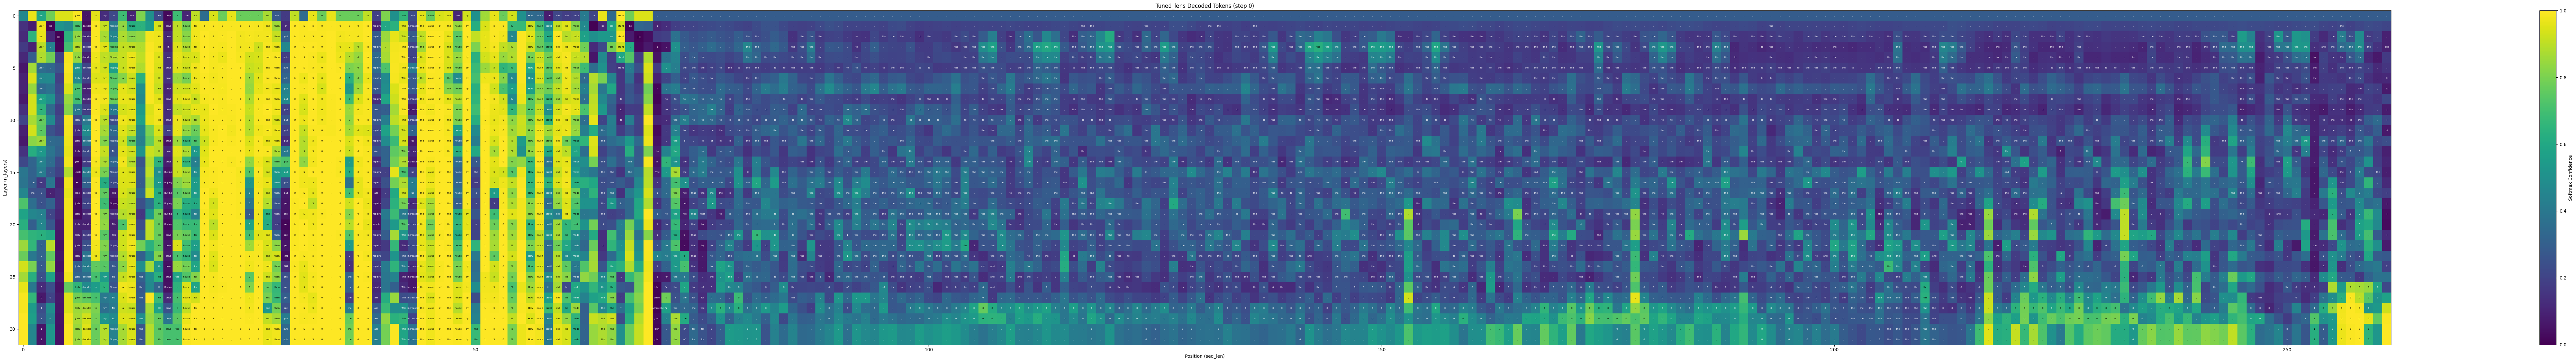

In [8]:
# 画图测试
step_idxs = [0]
for step_idx in step_idxs:
    fig_w = max(8.0, seq_len * 0.35)
    fig_h = max(6.0, n_layers * 0.35)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    im = ax.imshow(pred_confidences_all[step_idx], origin='upper', aspect='auto', cmap='viridis', vmin=0.0, vmax=1.0)

    for layer_idx in range(n_layers):
        for pos in range(seq_len):
            text_color = 'white' if pred_confidences_all[step_idx, layer_idx, pos] < 0.6 else 'black'
            ax.text(pos, layer_idx, decoded_tokens_all[step_idx, layer_idx, pos], ha='center', va='center', color=text_color, fontsize=5)

    ax.set_xlabel('Position (seq_len)')
    ax.set_ylabel('Layer (n_layers)')
    ax.set_title(f'{lens_type.capitalize()} Decoded Tokens (step {step_idx})')
    fig.colorbar(im, ax=ax, label='Softmax Confidence')

    output_path = f'{repo_root}/visualization/huashan2/imgs/{lens_type}_tokens_step{step_idx}_L32.png'
    plt.tight_layout()
    plt.savefig(output_path, dpi=250)
    plt.show()

plot attn map

In [ ]:
from visualization.utils.AttnWidget import DLLMAttnVisualizer

attn_weights = np.load(f"{repo_root}/visualization/huashan2/data/attentions_gsm8k_qid_0_L192.npy")

print("loaded shape:", attn_weights.shape)
prompt_len = attn_weights.shape[-1] - 192
viz = DLLMAttnVisualizer(attn_weights, decoded_tokens=decoded_tokens_all, pred_confidences=pred_confidences_all, prompt_len=prompt_len)
viz.show()


loaded shape: (64, 32, 32, 262, 262)
